# Bài Ôn Tập: Phân Tích Dữ Liệu & Học Sâu (Titanic)




## Import các thư viện cần thiết

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")


---
## PHẦN 1: TIỀN XỬ LÝ VÀ TRỰC QUAN HÓA DỮ LIỆU


In [17]:
df = sns.load_dataset('titanic')

# 5 dòng đầu tiên
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [18]:
# Thông tin tổng quan về dữ liệu
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### Câu 2: Xử lý giá trị khuyết (1.5 điểm)



In [19]:
# Đếm số lượng giá trị khuyết ở mỗi cột
print("Số giá trị khuyết theo từng cột:")
print(df.isnull().sum())


Số giá trị khuyết theo từng cột:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [20]:
# Xóa hoàn toàn cột 'deck' vì có quá nhiều giá trị khuyết
df = df.drop(columns=['deck'])

# Điền khuyết cột 'age' bằng giá trị Trung bình
mean_age = df['age'].mean()
df['age'] = df['age'].fillna(mean_age)

print(f"Tuổi trung bình dùng để điền khuyết: {mean_age:.2f}")
print("\nSố giá trị khuyết sau khi xử lý:")
print(df.isnull().sum())


Tuổi trung bình dùng để điền khuyết: 29.70

Số giá trị khuyết sau khi xử lý:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


### Câu 3: Phân tích và Trực quan hóa (2.0 điểm)



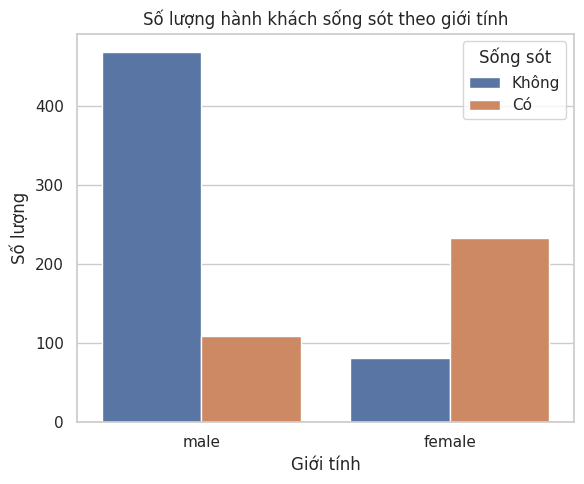

In [21]:
# 1. Biểu đồ số lượng hành khách sống sót phân chia theo giới tính
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='sex', hue='survived')
plt.title('Số lượng hành khách sống sót theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
plt.legend(title='Sống sót', labels=['Không', 'Có'])
plt.tight_layout()
plt.show()


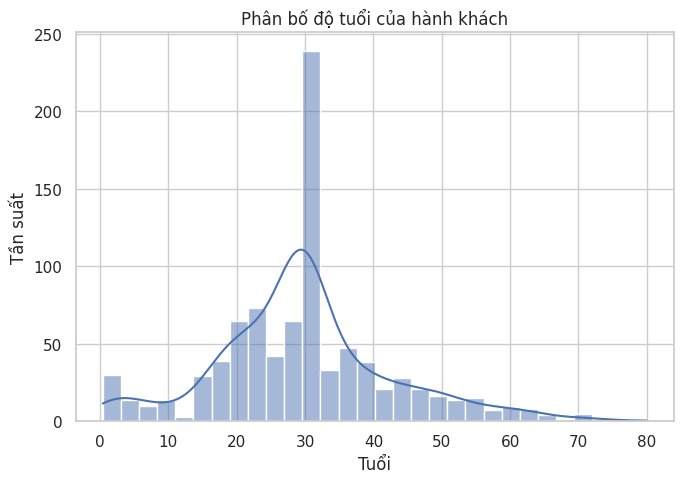

In [22]:
# 2. Biểu đồ phân bố độ tuổi
plt.figure(figsize=(7, 5))
sns.histplot(df['age'], kde=True, bins=30)
plt.title('Phân bố độ tuổi của hành khách')
plt.xlabel('Tuổi')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()


          survived    pclass       age      fare
survived  1.000000 -0.338481 -0.069809  0.257307
pclass   -0.338481  1.000000 -0.331339 -0.549500
age      -0.069809 -0.331339  1.000000  0.091566
fare      0.257307 -0.549500  0.091566  1.000000


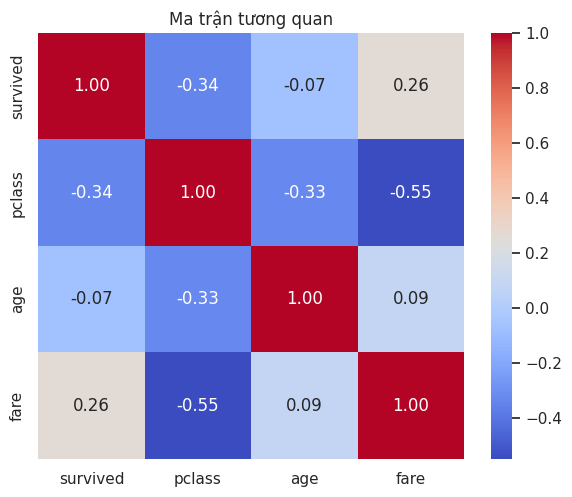

In [23]:
# 3. Ma trận tương quan giữa các biến số
cols_so = ['survived', 'pclass', 'age', 'fare']
corr_matrix = df[cols_so].corr()
print(corr_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Ma trận tương quan')
plt.tight_layout()
plt.show()


### Câu 4: Mã hóa dữ liệu (1.5 điểm)



In [24]:
# Label Encoding cho cột 'sex'
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# One-Hot Encoding cho cột 'embarked'
df_embarked_encoded = pd.get_dummies(df['embarked'], prefix='embarked')
df = pd.concat([df, df_embarked_encoded], axis=1)

df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,embarked_C,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,False,False,True
1,1,1,1,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,True,False,False
2,1,3,1,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,False,False,True
3,1,1,1,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,False,False,True
4,0,3,0,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,False,False,True


---
## PHẦN 2: XÂY DỰNG MÔ HÌNH HỌC SÂU CƠ BẢN



In [25]:
X = df[['pclass', 'sex', 'age']]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test:", X_test.shape)

# Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Kích thước X_train: (712, 3)
Kích thước X_test: (179, 3)


### Câu 6: Xây dựng mạng Nơ-ron nhân tạo - ANN (2.5 điểm)

Mô hình phân loại nhị phân: Sequential -> Dense(16, relu) -> Dense(1, sigmoid).


In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [27]:
model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(3,)),
    layers.Dense(1, activation='sigmoid')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=16,
    verbose=1
)


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6094 - loss: 0.7304 - val_accuracy: 0.6806 - val_loss: 0.6425
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6109 - loss: 0.6634 - val_accuracy: 0.7083 - val_loss: 0.5771
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6172 - loss: 0.6145 - val_accuracy: 0.7083 - val_loss: 0.5259
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6891 - loss: 0.5783 - val_accuracy: 0.8472 - val_loss: 0.4854
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7641 - loss: 0.5507 - val_accuracy: 0.8611 - val_loss: 0.4542
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7734 - loss: 0.5298 - val_accuracy: 0.8750 - val_loss: 0.4258
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7719 - loss: 0.5141 - val_accuracy: 0.8611 - val_loss: 0.4065
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7719 - loss: 0.5017 - val_accuracy: 0.8611 - val_

In [29]:
# Đánh giá mô hình trên tập test
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=2)
print(f"\nĐộ chính xác (Accuracy) trên tập test: {test_accuracy:.4f}")
print(f"Loss trên tập test: {test_loss:.4f}")


6/6 - 0s - 23ms/step - accuracy: 0.7933 - loss: 0.4396

Độ chính xác (Accuracy) trên tập test: 0.7933
Loss trên tập test: 0.4396


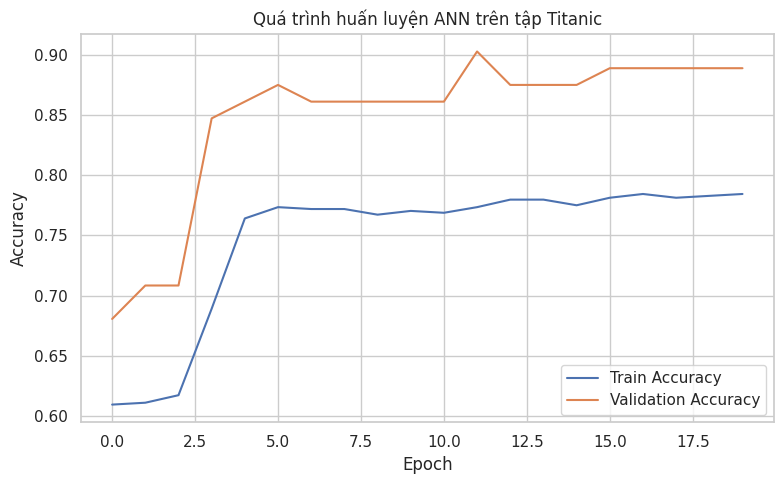

In [30]:
# (Tùy chọn) Trực quan hóa quá trình huấn luyện
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Quá trình huấn luyện ANN trên tập Titanic')
plt.legend()
plt.tight_layout()
plt.show()
